# 🫒🍈 YOLOv8 Fruit Detection with out training — Olives & Figs
> Uses the **official pretrained YOLOv8s** model from Ultralytics (no training required).
> Upload your fruit images below and see bounding-box results instantly.

**Steps:**
1. Install dependencies
2. Load YOLOv8s from Ultralytics
3. Upload your images
4. Run detection & display results

## ① Install Ultralytics

In [3]:
!pip install ultralytics --quiet
print('✅ Ultralytics installed')

✅ Ultralytics installed


## ② Import Libraries

In [2]:
import os
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries imported


## ③ Load the Official YOLOv8s Model (No Training Needed)

> The model is downloaded automatically from Ultralytics the first time you run this cell.
> It is the **original pretrained** `yolov8s.pt` — trained on COCO 80 classes.

In [4]:
# Load official pretrained YOLOv8s from Ultralytics
model = YOLO('yolov8s.pt')  # Downloads automatically if not cached

print(f'✅ Model loaded: YOLOv8s')
print(f'   Architecture : {model.model.__class__.__name__}')
print(f'   Task         : {model.task}')
print(f'   Classes      : {len(model.names)} (COCO)')
print(f'\n📌 NOTE: This model is trained on COCO dataset (80 classes).')
print(   '         It will detect objects it was trained on.')
print(   '         For olive/fig-specific detection, a fine-tuned model would be needed.')

✅ Model loaded: YOLOv8s
   Architecture : DetectionModel
   Task         : detect
   Classes      : 80 (COCO)

📌 NOTE: This model is trained on COCO dataset (80 classes).
         It will detect objects it was trained on.
         For olive/fig-specific detection, a fine-tuned model would be needed.


## ④ Upload Your Images

In [5]:
print('📂 Please select your fruit images to upload...')
uploaded = files.upload()

image_paths = []
for filename in uploaded.keys():
    filepath = f'/content/{filename}'
    with open(filepath, 'wb') as f:
        f.write(uploaded[filename])
    image_paths.append(filepath)
    print(f'  ✅ Uploaded: {filename}')

print(f'\n📊 Total images uploaded: {len(image_paths)}')

📂 Please select your fruit images to upload...


Saving 202511230920442044.webp to 202511230920442044.webp
  ✅ Uploaded: 202511230920442044.webp

📊 Total images uploaded: 1


## ⑤ Run Detection

In [6]:
# ── Detection Settings ──────────────────────────────────────────────────
CONF_THRESHOLD = 0.50   # Minimum confidence to show a detection (0.0 – 1.0)
IOU_THRESHOLD  = 0.45   # NMS IoU threshold
IMG_SIZE       = 640    # Inference image size
# ────────────────────────────────────────────────────────────────────────

results_list = []

for img_path in image_paths:
    result = model.predict(
        source     = img_path,
        conf       = CONF_THRESHOLD,
        iou        = IOU_THRESHOLD,
        imgsz      = IMG_SIZE,
        verbose    = False
    )
    results_list.append((img_path, result[0]))
    print(f'🔍 {Path(img_path).name} → {len(result[0].boxes)} detection(s)')

print('\n✅ Detection complete!')

🔍 202511230920442044.webp → 0 detection(s)

✅ Detection complete!


## ⑥ Visualise Results

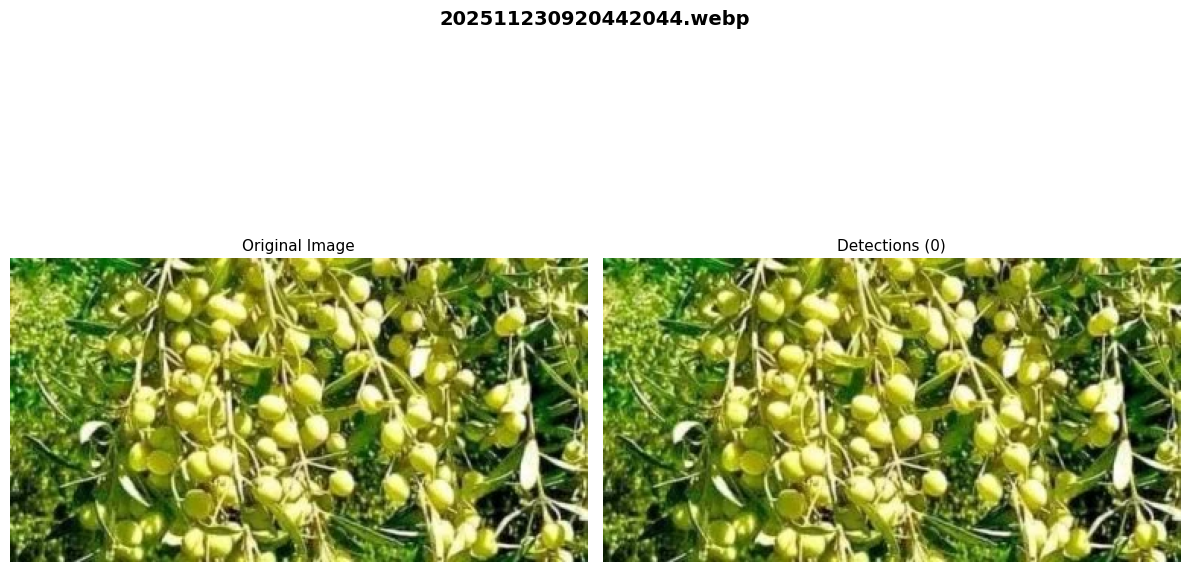

In [7]:
def plot_detections(img_path, result, figsize=(12, 8)):
    """Draw bounding boxes and labels on the image."""
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    boxes  = result.boxes
    names  = result.names

    # Color palette — one per class
    np.random.seed(42)
    colors = {cid: tuple(np.random.randint(50, 230, 3).tolist()) for cid in names}

    detected_labels = []

    for box in boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf  = float(box.conf[0])
        cls   = int(box.cls[0])
        label = names[cls]
        color = colors[cls]

        # Draw rectangle
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), color, 2)

        # Label background
        text      = f'{label} {conf:.2f}'
        (tw, th), _ = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
        cv2.rectangle(img_rgb, (x1, y1 - th - 8), (x1 + tw + 4, y1), color, -1)
        cv2.putText(img_rgb, text, (x1 + 2, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)

        detected_labels.append((label, conf, cls))

    # ── Plot ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(Path(img_path).name, fontsize=14, fontweight='bold')

    # Original
    orig = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
    axes[0].imshow(orig)
    axes[0].set_title('Original Image', fontsize=11)
    axes[0].axis('off')

    # Detected
    axes[1].imshow(img_rgb)
    axes[1].set_title(f'Detections ({len(boxes)})', fontsize=11)
    axes[1].axis('off')

    # Legend patches
    seen = {}
    for lbl, conf, cls in detected_labels:
        if lbl not in seen:
            c = [v / 255 for v in colors[cls]]
            seen[lbl] = mpatches.Patch(color=c, label=lbl)
    if seen:
        axes[1].legend(handles=list(seen.values()),
                       loc='upper right', fontsize=9,
                       framealpha=0.8)

    plt.tight_layout()
    plt.show()

    return detected_labels


# ── Run visualisation ───────────────────────────────────────────────────
for img_path, result in results_list:
    detections = plot_detections(img_path, result)

## ⑦ Detection Summary Table

In [8]:
print('=' * 60)
print(f'  DETECTION SUMMARY')
print('=' * 60)

for img_path, result in results_list:
    name  = Path(img_path).name
    boxes = result.boxes
    names = result.names

    print(f'\n📷 Image : {name}')
    print(f'   Total detections : {len(boxes)}')

    if len(boxes) == 0:
        print('   ⚠️  No objects detected. Try lowering CONF_THRESHOLD.')
    else:
        print(f'   {"#":<4} {"Class":<20} {"Confidence":>12} {"BBox (x1,y1,x2,y2)"}')
        print('   ' + '-' * 55)
        for i, box in enumerate(boxes, 1):
            cls   = int(box.cls[0])
            conf  = float(box.conf[0])
            coords = [int(v) for v in box.xyxy[0]]
            print(f'   {i:<4} {names[cls]:<20} {conf:>11.2%}  {coords}')

print('\n' + '=' * 60)

  DETECTION SUMMARY

📷 Image : 202511230920442044.webp
   Total detections : 0
   ⚠️  No objects detected. Try lowering CONF_THRESHOLD.



## ⑨ Model Info & Class List or origenal model

In [9]:
print('YOLOv8s — COCO Class List (80 classes)')
print('=' * 50)
for cid, cname in model.names.items():
    print(f'  [{cid:2d}]  {cname}')

YOLOv8s — COCO Class List (80 classes)
  [ 0]  person
  [ 1]  bicycle
  [ 2]  car
  [ 3]  motorcycle
  [ 4]  airplane
  [ 5]  bus
  [ 6]  train
  [ 7]  truck
  [ 8]  boat
  [ 9]  traffic light
  [10]  fire hydrant
  [11]  stop sign
  [12]  parking meter
  [13]  bench
  [14]  bird
  [15]  cat
  [16]  dog
  [17]  horse
  [18]  sheep
  [19]  cow
  [20]  elephant
  [21]  bear
  [22]  zebra
  [23]  giraffe
  [24]  backpack
  [25]  umbrella
  [26]  handbag
  [27]  tie
  [28]  suitcase
  [29]  frisbee
  [30]  skis
  [31]  snowboard
  [32]  sports ball
  [33]  kite
  [34]  baseball bat
  [35]  baseball glove
  [36]  skateboard
  [37]  surfboard
  [38]  tennis racket
  [39]  bottle
  [40]  wine glass
  [41]  cup
  [42]  fork
  [43]  knife
  [44]  spoon
  [45]  bowl
  [46]  banana
  [47]  apple
  [48]  sandwich
  [49]  orange
  [50]  broccoli
  [51]  carrot
  [52]  hot dog
  [53]  pizza
  [54]  donut
  [55]  cake
  [56]  chair
  [57]  couch
  [58]  potted plant
  [59]  bed
  [60]  dining table
 

---
### 📝 Notes for the Doctor

| Item | Detail |
|------|---------|
| **Model** | `yolov8s.pt` — official Ultralytics pretrained weights |
| **Training** | None — zero training, direct inference |
| **Dataset** | COCO (80 classes) |
| **Source** | `ultralytics` Python package (official) |
| **Inference size** | 640 × 640 (default) |

> *Because this model is trained on COCO, it detects general objects. Fine-tuning on a custom olives/figs dataset would be the next step for domain-specific accuracy.*